In [10]:
import pandas as pd
import numpy as np

# Load data
df_cal = pd.read_csv('calendar.csv')
df_stores = pd.read_csv('stores.csv')
df_trans = pd.read_csv('transactions.csv')

# Function to get basic EDA info
def get_eda_summary(df, name):
    summary = []
    summary.append(f"--- {name.upper()} ---")
    summary.append(f"Shape: {df.shape}")
    
    # Data types and missing values
    info_df = pd.DataFrame({
        'Type': df.dtypes,
        'Missing': df.isnull().sum(),
        '% Missing': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique': df.nunique()
    })
    summary.append("\nColumn Info:")
    summary.append(info_df.to_string())
    
    # Basic stats for numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        summary.append("\nNumeric Stats:")
        summary.append(df[numeric_cols].describe().T[['count', 'mean', 'min', 'max']].to_string())
        
    return "\n".join(summary)

print(get_eda_summary(df_cal, 'calendar.csv'))
print("\n" + "="*50 + "\n")
print(get_eda_summary(df_stores, 'stores.csv'))
print("\n" + "="*50 + "\n")
print(get_eda_summary(df_trans, 'transactions.csv'))

--- CALENDAR.CSV ---
Shape: (425, 15)

Column Info:
                    Type  Missing  % Missing  Unique
date                 str        0       0.00     425
day_of_week        int64        0       0.00       7
day_name             str        0       0.00       7
week_of_year       int64        0       0.00      52
month              int64        0       0.00      12
year               int64        0       0.00       2
quarter            int64        0       0.00       4
season               str        0       0.00       4
is_holiday          bool        0       0.00       2
holiday_name         str      407      95.76      14
is_payday           bool        0       0.00       2
is_weekend          bool        0       0.00       2
is_navidad_season   bool        0       0.00       2
is_buen_fin         bool        0       0.00       2
is_semana_santa     bool        0       0.00       2

Numeric Stats:
              count         mean     min     max
day_of_week   425.0     2.992941   

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load data
df_cal = pd.read_csv('calendar.csv')
df_stores = pd.read_csv('stores.csv')
df_trans = pd.read_csv('transactions.csv')

# 1. Clean transactions data algebraically
# amount_cash = amount_total - amount_card
mask_cash_amt = df_trans['amount_cash'].isnull()
df_trans.loc[mask_cash_amt, 'amount_cash'] = df_trans.loc[mask_cash_amt, 'amount_total'] - df_trans.loc[mask_cash_amt, 'amount_card']

# cash_transactions = total_transactions - card_transactions
mask_cash_tx = df_trans['cash_transactions'].isnull()
df_trans.loc[mask_cash_tx, 'cash_transactions'] = df_trans.loc[mask_cash_tx, 'total_transactions'] - df_trans.loc[mask_cash_tx, 'card_transactions']

# avg_ticket = amount_total / total_transactions
mask_avg_tkt = df_trans['avg_ticket'].isnull()
df_trans.loc[mask_avg_tkt, 'avg_ticket'] = df_trans.loc[mask_avg_tkt, 'amount_total'] / df_trans.loc[mask_avg_tkt, 'total_transactions']

# 2. Impute units_sold using Linear Regression per category
categories = df_trans['category'].unique()
r2_scores = {}

for cat in categories:
    mask_cat = df_trans['category'] == cat
    df_cat = df_trans[mask_cat]
    
    # Train data: where units_sold is NOT null
    train_data = df_cat[df_cat['units_sold'].notnull()]
    # Predict data: where units_sold IS null
    predict_data = df_cat[df_cat['units_sold'].isnull()]
    
    if len(train_data) > 0:
        X_train = train_data[['amount_total']]
        y_train = train_data['units_sold']
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        # Calculate R^2 on train data
        y_pred_train = model.predict(X_train)
        r2 = r2_score(y_train, y_pred_train)
        r2_scores[cat] = r2
        
        # Predict missing values
        if len(predict_data) > 0:
            X_pred = predict_data[['amount_total']]
            y_pred = model.predict(X_pred)
            # Assign predictions back to the original dataframe
            df_trans.loc[mask_cat & df_trans['units_sold'].isnull(), 'units_sold'] = np.round(y_pred)

# 3. Inner Join all datasets
df_merged = df_trans.merge(df_stores, on='store_id', how='inner')
df_merged = df_merged.merge(df_cal, on='date', how='inner')

# Summary for the output
missing_after = df_merged.isnull().sum()
output = []
output.append("--- R^2 Scores for units_sold Regression by Category ---")
for cat, r2 in r2_scores.items():
    output.append(f"{cat}: {r2:.4f}")

output.append("\n--- Merged Dataset Info ---")
output.append(f"Shape: {df_merged.shape}")
output.append(f"Remaining nulls in transactions columns:")
output.append(str(missing_after[['amount_cash', 'cash_transactions', 'avg_ticket', 'units_sold']]))

print("\n".join(output))

--- R^2 Scores for units_sold Regression by Category ---
Abarrotes: 0.7794
Bebidas: 0.7817
Cuidado_Personal: 0.7716
Electronica: 0.7858
Hogar: 0.7766
Ropa: 0.7772

--- Merged Dataset Info ---
Shape: (203958, 35)
Remaining nulls in transactions columns:
amount_cash          0
cash_transactions    0
avg_ticket           0
units_sold           0
dtype: int64


In [ ]:
# Exploratory Data Analysis (EDA) Computations
eda_output = []

# Insight A: Performance by Store Format & Region
format_region_sales = df_merged.groupby(['store_format', 'region'])['amount_total'].sum().reset_index()
format_region_sales = format_region_sales.sort_values(by='amount_total', ascending=False)
eda_output.append("--- Sales by Format & Region ---")
eda_output.append(format_region_sales.to_string())

# Insight B: Performance by Category
cat_sales = df_merged.groupby('category').agg({'amount_total': 'sum', 'units_sold': 'sum'}).reset_index()
cat_sales['avg_price_per_unit'] = cat_sales['amount_total'] / cat_sales['units_sold']
cat_sales = cat_sales.sort_values(by='amount_total', ascending=False)
eda_output.append("\n--- Sales by Category ---")
eda_output.append(cat_sales.to_string())

# Insight C: Impact of Replenishment Signal
# Let's check correlation of replenishment_signal with amount_total and total_transactions
corr_replenishment = df_merged[['replenishment_signal', 'amount_total', 'units_sold', 'total_transactions']].corr()
eda_output.append("\n--- Correlation with Replenishment Signal ---")
eda_output.append(corr_replenishment.to_string())

# Let's look at average sales when replenishment is HIGH vs LOW (using median as split)
median_repl = df_merged['replenishment_signal'].median()
df_merged['repl_level'] = np.where(df_merged['replenishment_signal'] > median_repl, 'High', 'Low')
repl_impact = df_merged.groupby('repl_level').agg({'amount_total': 'mean', 'units_sold': 'mean'}).reset_index()
eda_output.append("\n--- Average Performance by Replenishment Level ---")
eda_output.append(repl_impact.to_string())

# Insight D: Promotion Impact
promo_impact = df_merged.groupby('has_promotion').agg({'amount_total': 'mean', 'units_sold': 'mean'}).reset_index()
eda_output.append("\n--- Average Performance: Promotion vs No Promotion ---")
eda_output.append(promo_impact.to_string())

print("\n".join(eda_output))

--- Sales by Format & Region ---
   store_format     region  amount_total
3        Bodega    Oriente  4.013361e+09
12  Supercenter  Occidente  4.011855e+09
14  Supercenter        Sur  3.726147e+09
0        Bodega     Centro  3.295880e+09
2        Bodega  Occidente  3.192503e+09
1        Bodega      Norte  3.167080e+09
11  Supercenter      Norte  3.036199e+09
13  Supercenter    Oriente  2.342697e+09
7       Express  Occidente  1.716849e+09
4        Bodega        Sur  1.501592e+09
10  Supercenter     Centro  1.327664e+09
6       Express      Norte  1.307723e+09
9       Express        Sur  7.820700e+08
8       Express    Oriente  7.229343e+08
5       Express     Centro  6.468574e+08

--- Sales by Category ---
           category  amount_total  units_sold  avg_price_per_unit
0         Abarrotes  8.748550e+09  77198624.0          113.325213
3       Electronica  6.296238e+09  12843630.0          490.222631
4             Hogar  5.861226e+09  29837323.0          196.439407
5              Ropa 

In [13]:
df_merged['date'] = pd.to_datetime(df_merged['date'])

# Time Series Analysis Aggregations
# Weekly sales aggregation to reduce daily noise
df_merged['week_start'] = df_merged['date'] - pd.to_timedelta(df_merged['date'].dt.dayofweek, unit='d')

ts_region = df_merged.groupby(['week_start', 'region'])['amount_total'].sum().reset_index()
ts_category = df_merged.groupby(['week_start', 'category'])['amount_total'].sum().reset_index()
ts_format = df_merged.groupby(['week_start', 'store_format'])['amount_total'].sum().reset_index()
ts_overall = df_merged.groupby('week_start')['amount_total'].sum().reset_index()

print("Top 3 Weeks Overall:")
print(ts_overall.sort_values(by='amount_total', ascending=False).head(3))

print("\nTop Category during peak week:")
peak_week = ts_overall.sort_values(by='amount_total', ascending=False).iloc[0]['week_start']
print(ts_category[ts_category['week_start'] == peak_week].sort_values(by='amount_total', ascending=False).head(2))

Top 3 Weeks Overall:
   week_start  amount_total
46 2023-11-13  1.336104e+09
52 2023-12-25  1.201736e+09
51 2023-12-18  1.106153e+09

Top Category during peak week:
    week_start     category  amount_total
276 2023-11-13    Abarrotes  3.397797e+08
279 2023-11-13  Electronica  2.389612e+08


C:\Users\santino\AppData\Local\Temp\ipykernel_14308\833905555.py:5: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  df_merged['week_start'] = df_merged['date'] - pd.to_timedelta(df_merged['date'].dt.dayofweek, unit='d')


C:\Users\santino\AppData\Local\Temp\ipykernel_14308\2335856509.py:9: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  df_merged['week_start'] = df_merged['date'] - pd.to_timedelta(df_merged['date'].dt.dayofweek, unit='d')


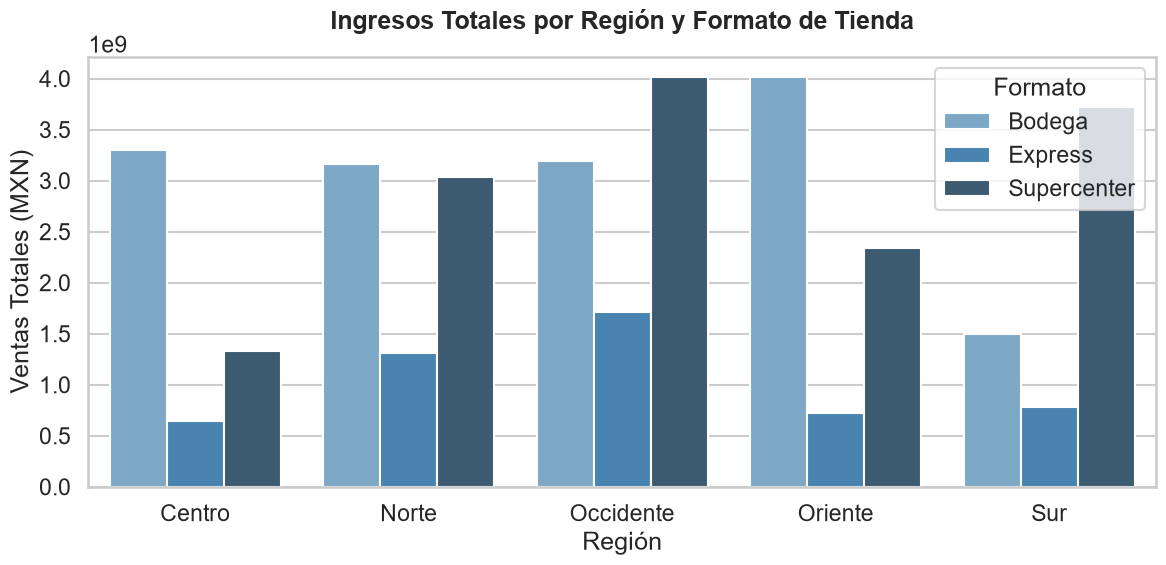

C:\Users\santino\AppData\Local\Temp\ipykernel_14308\2335856509.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x='amount_total', y='category', palette='viridis')


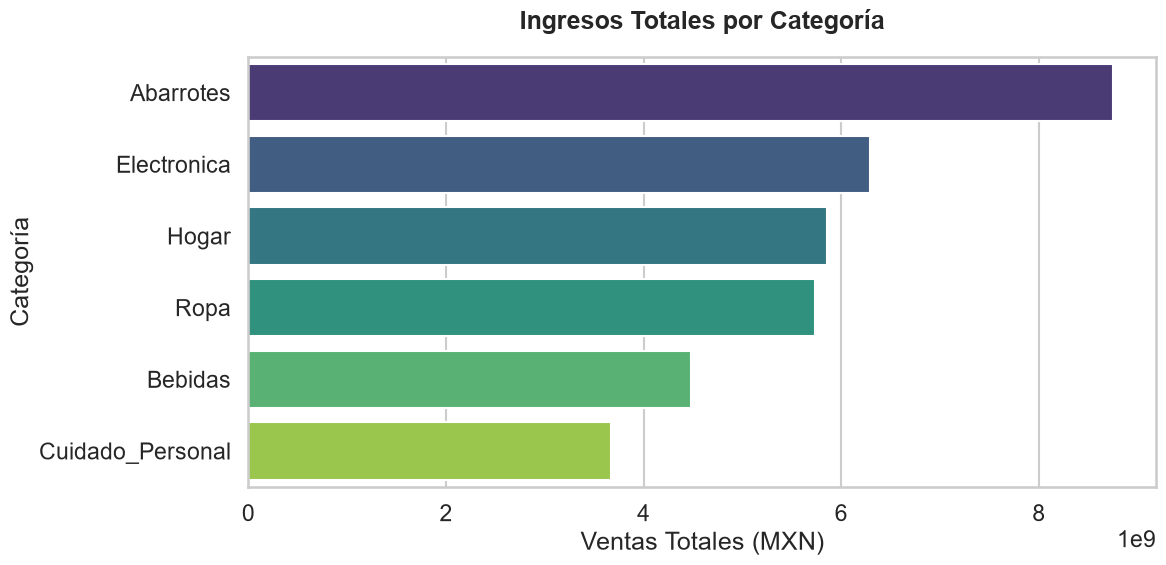

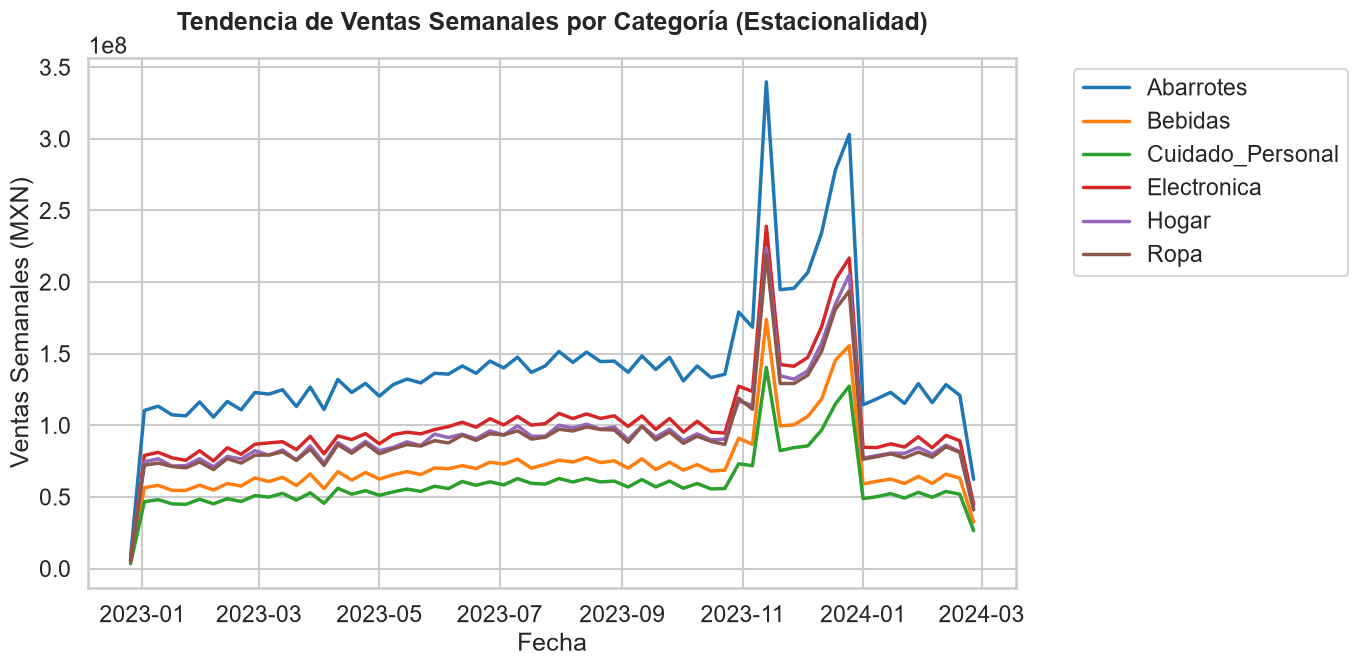

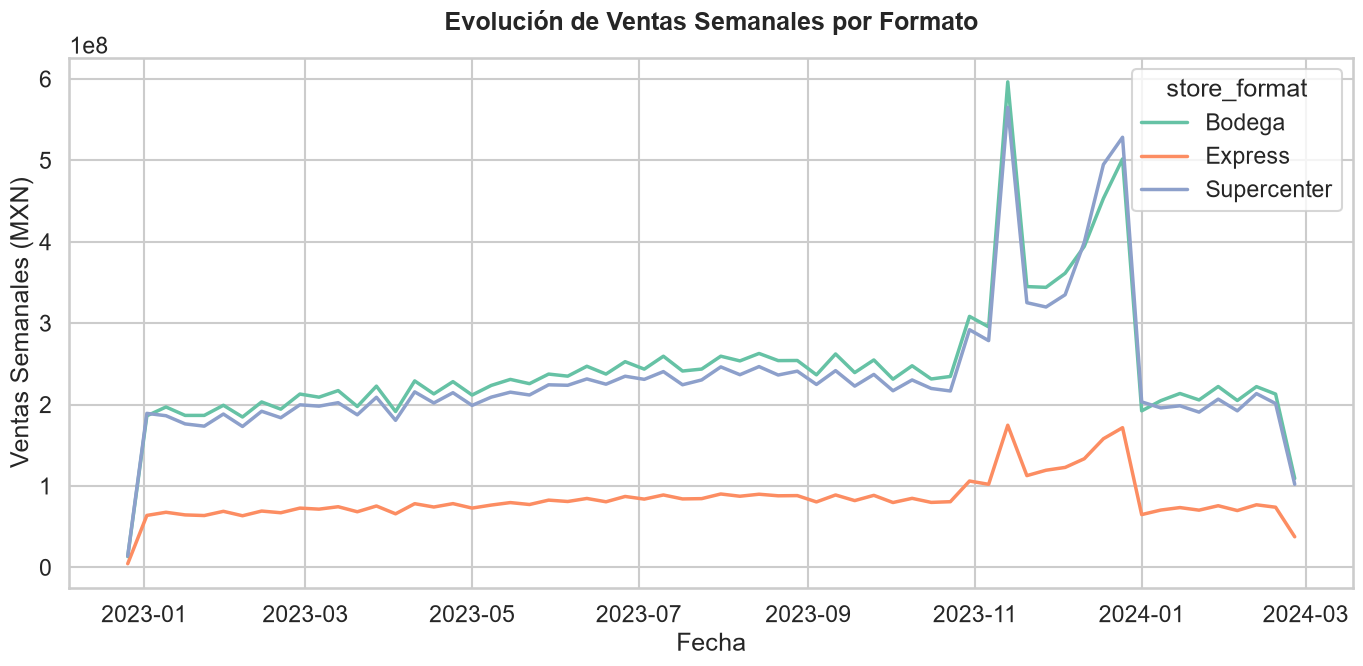

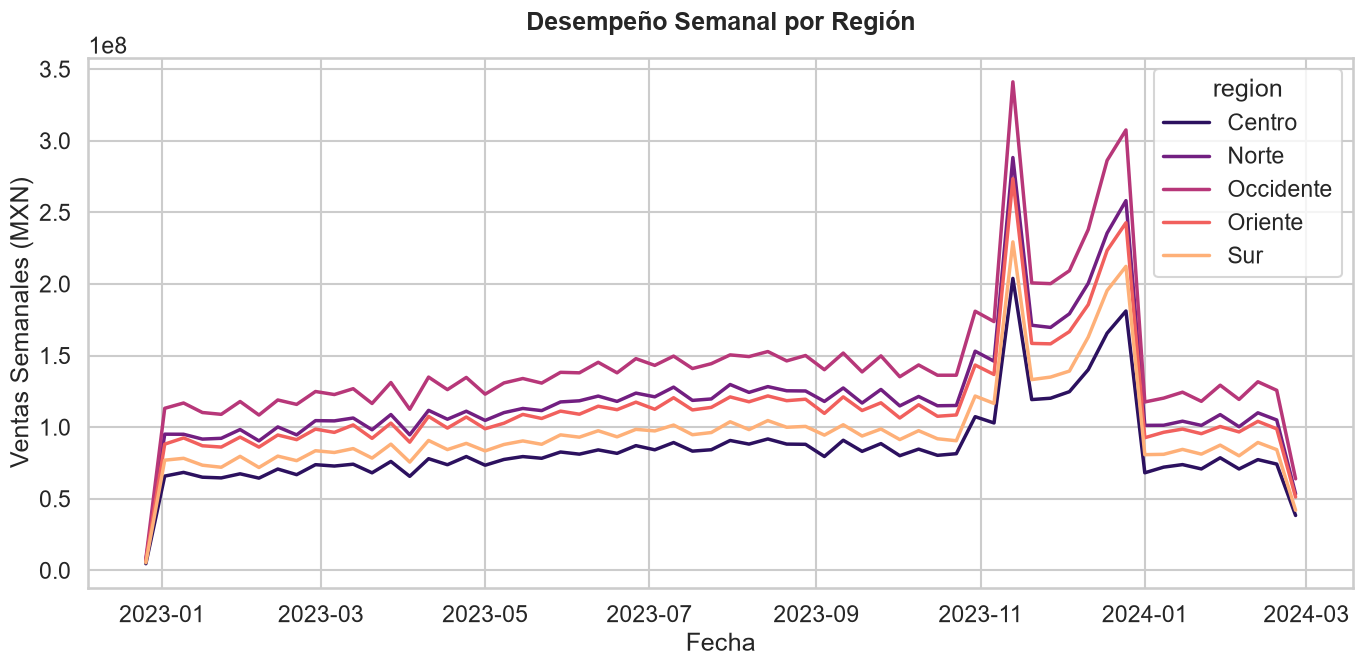

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
colors = sns.color_palette("husl", 8)

# change date to datetime
df_merged['date'] = pd.to_datetime(df_merged['date'])
df_merged['week_start'] = df_merged['date'] - pd.to_timedelta(df_merged['date'].dt.dayofweek, unit='d')

# ==========================================
# GRAPH 1: Sales by Region and Format
# ==========================================
plt.figure(figsize=(12, 6))
format_region = df_merged.groupby(['region', 'store_format'])['amount_total'].sum().reset_index()
sns.barplot(data=format_region, x='region', y='amount_total', hue='store_format', palette='Blues_d')
plt.title('Ingresos Totales por Región y Formato de Tienda', pad=20, fontweight='bold')
plt.ylabel('Ventas Totales (MXN)')
plt.xlabel('Región')
plt.legend(title='Formato')
plt.tight_layout()
plt.savefig('eda_1_region_format.png', dpi=300)
plt.show()

# ==========================================
# GRAPH 2: Sales by Category
# ==========================================
plt.figure(figsize=(12, 6))
cat_sales = df_merged.groupby('category')['amount_total'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_sales, x='amount_total', y='category', palette='viridis')
plt.title('Ingresos Totales por Categoría', pad=20, fontweight='bold')
plt.xlabel('Ventas Totales (MXN)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.savefig('eda_2_category.png', dpi=300)
plt.show()

# ==========================================
# GRAPH 3: Time Series by Category
# ==========================================
plt.figure(figsize=(14, 7))
ts_cat = df_merged.groupby(['week_start', 'category'])['amount_total'].sum().reset_index()
sns.lineplot(data=ts_cat, x='week_start', y='amount_total', hue='category', linewidth=2.5, palette='tab10')
plt.title('Tendencia de Ventas Semanales por Categoría (Estacionalidad)', pad=20, fontweight='bold')
plt.ylabel('Ventas Semanales (MXN)')
plt.xlabel('Fecha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eda_3_ts_category.png', dpi=300)
plt.show()

# ==========================================
# GRAPH 4: Time Series by Store Format
# ==========================================
plt.figure(figsize=(14, 7))
ts_format = df_merged.groupby(['week_start', 'store_format'])['amount_total'].sum().reset_index()
sns.lineplot(data=ts_format, x='week_start', y='amount_total', hue='store_format', linewidth=2.5, palette='Set2')
plt.title('Evolución de Ventas Semanales por Formato', pad=20, fontweight='bold')
plt.ylabel('Ventas Semanales (MXN)')
plt.xlabel('Fecha')
plt.tight_layout()
plt.savefig('eda_4_ts_format.png', dpi=300)
plt.show()

# ==========================================
# GRAPH 5: Time Series by Region
# ==========================================
plt.figure(figsize=(14, 7))
ts_region = df_merged.groupby(['week_start', 'region'])['amount_total'].sum().reset_index()
sns.lineplot(data=ts_region, x='week_start', y='amount_total', hue='region', linewidth=2.5, palette='magma')
plt.title('Desempeño Semanal por Región', pad=20, fontweight='bold')
plt.ylabel('Ventas Semanales (MXN)')
plt.xlabel('Fecha')
plt.tight_layout()
plt.savefig('eda_5_ts_region.png', dpi=300)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# Feature Engineering at Store Level
store_features = df_merged.groupby('store_id').agg(
    total_sales=('amount_total', 'sum'),
    total_units=('units_sold', 'sum'),
    avg_replenishment=('replenishment_signal', 'mean'),
    size_sqm=('size_sqm', 'first'),
    num_checkouts=('num_checkouts', 'first'),
    store_format=('store_format', 'first')
).reset_index()

# Average ticket by Store
transactions_per_store = df_merged.groupby('store_id')['total_transactions'].sum().reset_index()
store_features = store_features.merge(transactions_per_store, on='store_id')
store_features['avg_ticket'] = store_features['total_sales'] / store_features['total_transactions']

# Sensibility to Promotion (Lift)
promo_sales = df_merged[df_merged['has_promotion']==1].groupby('store_id')['amount_total'].mean().reset_index(name='promo_avg')
nopromo_sales = df_merged[df_merged['has_promotion']==0].groupby('store_id')['amount_total'].mean().reset_index(name='nopromo_avg')
promo_elasticity = promo_sales.merge(nopromo_sales, on='store_id', how='outer')
promo_elasticity['promo_lift'] = (promo_elasticity['promo_avg'] / promo_elasticity['nopromo_avg']).fillna(1)
store_features = store_features.merge(promo_elasticity[['store_id', 'promo_lift']], on='store_id', how='left').fillna(1)

# Stationary Dependency (Buen Fin + Navidad)
peak_mask = df_merged['is_buen_fin'] | df_merged['is_navidad_season']
peak_sales = df_merged[peak_mask].groupby('store_id')['amount_total'].sum().reset_index(name='peak_sales')
store_features = store_features.merge(peak_sales, on='store_id', how='left').fillna(0)
store_features['peak_dependence'] = store_features['peak_sales'] / store_features['total_sales']

# 3. Scaling and K-Means
features_model = ['total_sales', 'total_units', 'avg_replenishment', 'size_sqm', 'num_checkouts', 'avg_ticket', 'promo_lift', 'peak_dependence']
X = store_features[features_model]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal K 
best_k = 2
best_score = -1
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k} Silhouette: {score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k

# Force to K=4 to get better granularity (Top, High, Mid, Low)
final_k = 4
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
store_features['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Summary
cluster_summary = store_features.groupby('cluster').agg({
    'store_id': 'count',
    'total_sales': 'mean',
    'size_sqm' : 'mean' ,
    'avg_ticket': 'mean',
    'avg_replenishment': 'mean',
    'promo_lift': 'mean',
    'peak_dependence': 'mean'
}).rename(columns={'store_id': 'num_stores'})

print("\n--- PERFIL DE CLÚSTERES (K=4) ---")
print(cluster_summary.to_string())

K=2 Silhouette: 0.4582
K=3 Silhouette: 0.3200
K=4 Silhouette: 0.3200
K=5 Silhouette: 0.2937
K=6 Silhouette: 0.2612

--- PERFIL DE CLÚSTERES (K=4) ---
         num_stores   total_sales      size_sqm  avg_ticket  avg_replenishment  promo_lift  peak_dependence
cluster                                                                                                    
0                24  3.846709e+08   5807.500000  244.412215         617.195171    1.001444         0.130911
1                10  5.637881e+08   5161.100000  343.585782         647.760051    1.005909         0.129965
2                20  7.222281e+08  11830.450000  281.404039        1001.880593    1.000007         0.142705
3                26  2.106487e+08   1987.846154  280.072087         301.008094    1.000293         0.124451


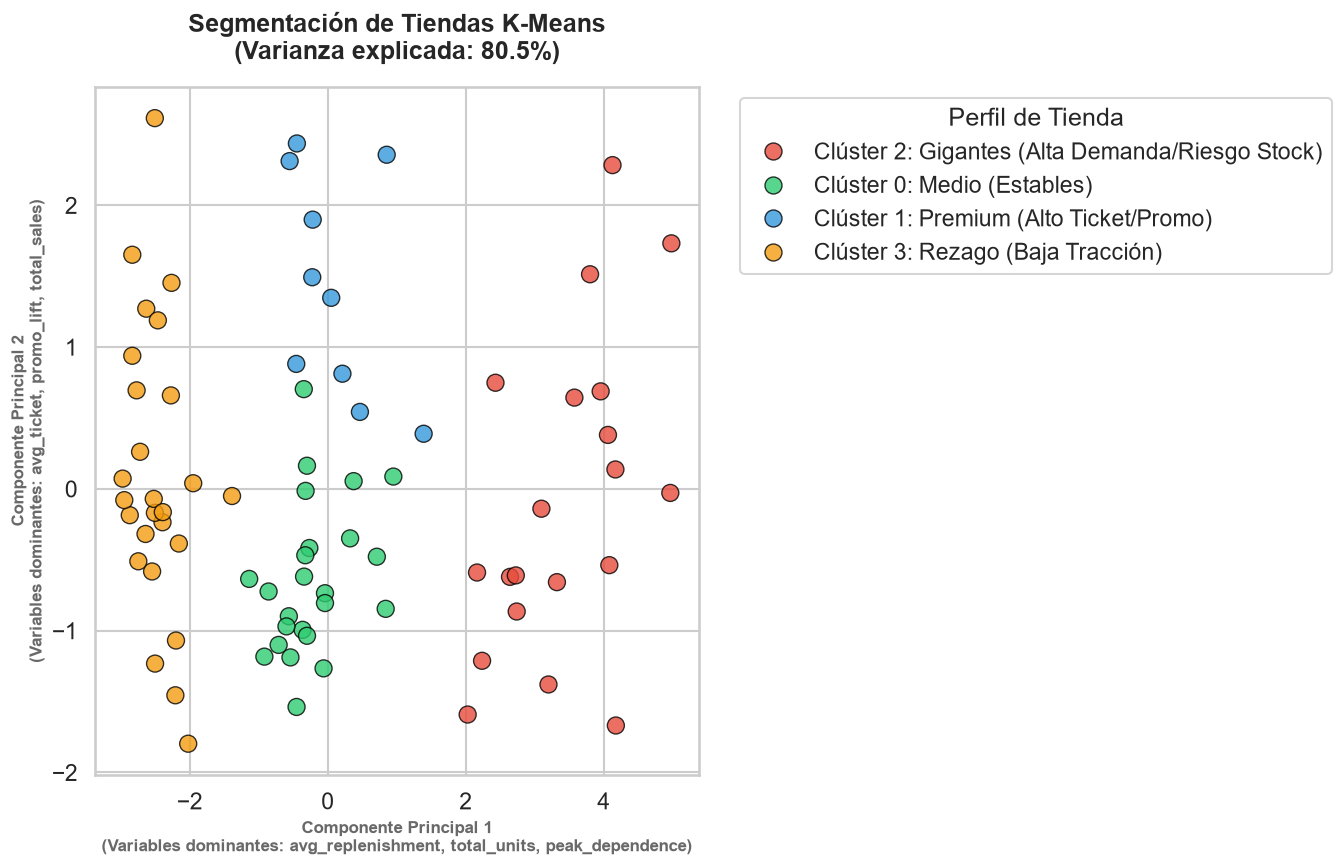

In [17]:

cluster_names = {
    0: 'Clúster 0: Medio (Estables)',
    1: 'Clúster 1: Premium (Alto Ticket/Promo)',
    2: 'Clúster 2: Gigantes (Alta Demanda/Riesgo Stock)',
    3: 'Clúster 3: Rezago (Baja Tracción)'
}
store_features['cluster_name'] = store_features['cluster'].map(cluster_names)

# PCA (Reduction to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
store_features['PCA_1'] = X_pca[:, 0]
store_features['PCA_2'] = X_pca[:, 1]
var_exp = pca.explained_variance_ratio_.sum() * 100

# Extract most important variables by component
# Create DataFrame with absolute weights of each variable
components_df = pd.DataFrame(pca.components_, columns=features_model, index=['PC1', 'PC2'])

# Top 3 variables in Component 1 (X Axis)
top_features_pc1 = components_df.iloc[0].abs().sort_values(ascending=False).head(3).index.tolist()
label_pc1 = f"Componente Principal 1\n(Variables dominantes: {', '.join(top_features_pc1)})"

# Top 3 variables in Component 2 (Y Axis)
top_features_pc2 = components_df.iloc[1].abs().sort_values(ascending=False).head(3).index.tolist()
label_pc2 = f"Componente Principal 2\n(Variables dominantes: {', '.join(top_features_pc2)})"

# Scatter plot
plt.figure(figsize=(14, 9)) # Ligeramente más alto para acomodar los nuevos títulos de los ejes
sns.set_theme(style="whitegrid", context="talk")

sns.scatterplot(
    data=store_features, 
    x='PCA_1', 
    y='PCA_2', 
    hue='cluster_name',
    palette=['#e74c3c', '#2ecc71', '#3498db', '#f39c12'], 
    s=150, 
    alpha=0.8,
    edgecolor='black'
)

plt.title(f'Segmentación de Tiendas K-Means\n(Varianza explicada: {var_exp:.1f}%)', pad=20, fontweight='bold')

# Inyectamos las etiquetas dinámicas extraídas matemáticamente
plt.xlabel(label_pc1, fontsize=12, fontweight='bold', color='dimgrey')
plt.ylabel(label_pc2, fontsize=12, fontweight='bold', color='dimgrey')

plt.legend(title='Perfil de Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('cluster_pca_explicable.png', dpi=300)
plt.show()
